In [137]:
# %%capture
# %pip install -q --upgrade pip setuptools wheel
# %pip install -q "numpy<2"
# %pip install -q tellurium
# import IPython
# IPython.Application.instance().kernel.do_shutdown(True)

To use GPU for training the model, 
1. Make sure you have a GPU that has Cuda support by NVIDIA
2. Create conda environment for installing torch. Be careful about compatibility between Python, Tellurium and Pytorch. Using latest version for all packages should work. But if something goes wrong, it is worth being careful about compatibility.
3. Install pytorch for GPU:
    ```bash
    conda install pytorch-gpu -c defaults
    ```
    or
    
    ```bash
    mamba install pytorch-gpu -c defaults
    ```
4. Reload your VSCode, select interpreter and environment relative to the conda environment where you installed torch
5. Run this piece of code:
    ```python
    import torch
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)
    ```
6. If it prints "Using device: cuda", you have correctly set up your environment. If it prints "Using device: cpu", something went wrong.

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib # Added this import
import tellurium as te
from sklearn.model_selection import train_test_split
from IPython.display import Audio
import numpy as np

In [25]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: cuda


In [26]:
MM = te.loada('''
  ->x; q*y-x*y+x*(1-x)
  ->y; -q*y-x*y+f*z
  ->z; e*(x-z)
  x=1
  y=1
  z=1
// Parameters
  q=0.1
  f=0.1
  e=0.1
  ''')
#r2.simulate(0,10,1000)
#r2.plot(logx=False)
result = MM.simulate(0, 500, 1001)
#MM.plot()

(512, 40)


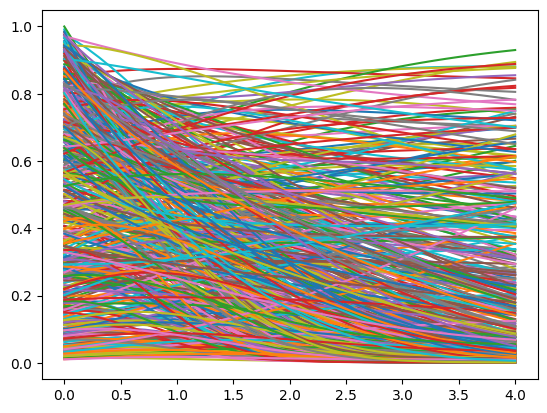

In [27]:
N = 512 # total number of sims
L = 40 # number of points
T = 4 # time length
kmin = -1
kmax = 1
xmin = 0.01
xmax = 1
params=[]
sequences=[]
for i in range(N):
  x = np.random.uniform(xmin, xmax)
  y = np.random.uniform(xmin, xmax)
  z = np.random.uniform(xmin, xmax)
  q = 10**np.random.uniform(-3, -1.3)#10**np.random.uniform(kmin, kmax)
  f = np.random.uniform(0.5, 3)#10**np.random.uniform(kmin, kmax)
  e = 10**np.random.uniform(-3, -1)#10**np.random.uniform(kmin, kmax)
  MM.reset()
  MM.x = x; MM.y = y; MM.z = z; MM.q = q; MM.f = f; MM.e = e
  result = MM.simulate(0, T, L, ["time", "x"])
  TIME = result[:,0].astype(np.float32)
  VAR_A = result[:,1].astype(np.float32)
  #params.append([np.log10(A0), np.log10(k)])
  sequences.append(VAR_A)
  plt.plot(TIME, VAR_A)

sequences = np.stack(sequences, axis=0)
print(sequences.shape)

In [28]:
def split_trajectory(seq):
    mid = seq.shape[1] // 2
    X = seq[:,:mid]        # shape (T/2, D)
    y = seq[:,mid:]        # shape (T/2, D)
    return X, y

In [29]:
class Encoder(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=1):
        super().__init__()
        self.fc = nn.Linear(1, hidden_dim)
        # self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True)
    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        x = self.fc(x)
        x = torch.relu(x)
        # x = self.fc2(x)
        # x = torch.relu(x)
        _, (h, c) = self.lstm(x)
        return h, c

class Decoder(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        # self.fc = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
    def forward(self, x, hidden):
        # x: (batch, 1, input_dim)
        out, hidden = self.lstm(x, hidden)
        # out = self.fc(out)
        # out = torch.relu(out)
        pred = self.fc2(out)
        return pred, hidden

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    def forward(self, src, tgt_len, teacher_forcing_ratio=0.5, tgt=None):
        """
        src: (batch, src_len, 1)
        tgt_len: number of future steps to predict
        tgt: (batch, tgt_len, 1) – only used during training
        """
        batch_size = src.size(0)
        device = src.device
        h, c = self.encoder(src)
        # first decoder input = last input value
        decoder_input = src[:, -1:, :]
        outputs = torch.zeros(batch_size, tgt_len, 1, device=device)
        hidden = (h, c)
        for t in range(tgt_len):
            out, hidden = self.decoder(decoder_input, hidden)
            outputs[:, t:t+1, :] = out
            if tgt is not None and torch.rand(1).item() < teacher_forcing_ratio:
                decoder_input = tgt[:, t:t+1, :]
            else:
                decoder_input = out
        return outputs

In [30]:
print(sequences.shape)
first_half, second_half = split_trajectory(sequences)
print(first_half.shape, second_half.shape)
X_train_np, X_test_np, Y_train_np, Y_test_np = train_test_split(
    first_half, second_half, train_size=0.8, shuffle=True, random_state=42
)
X_train = torch.from_numpy(X_train_np).to(device)
Y_train = torch.from_numpy(Y_train_np).to(device)
X_test  = torch.from_numpy(X_test_np).to(device)
Y_test  = torch.from_numpy(Y_test_np).to(device)
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)
X_train = X_train.unsqueeze(-1)
Y_train = Y_train.unsqueeze(-1)
X_test  = X_test.unsqueeze(-1)
Y_test  = Y_test.unsqueeze(-1)
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(512, 40)
(512, 20) (512, 20)
torch.Size([409, 20]) torch.Size([409, 20]) torch.Size([103, 20]) torch.Size([103, 20])
torch.Size([409, 20, 1]) torch.Size([409, 20, 1]) torch.Size([103, 20, 1]) torch.Size([103, 20, 1])


In [71]:
encoder = Encoder(hidden_dim=128, num_layers=1).to(device)
decoder = Decoder(hidden_dim=128, num_layers=1).to(device)
model = Seq2Seq(encoder, decoder).to(device)

In [72]:
# --- 3. Train the model ---
criterion = nn.MSELoss()
train_losses = []

In [73]:
optimizer = optim.Adam(model.parameters(), lr=1e-5)

In [74]:
epochs = 1000
TFR = 0.0
tgt_len = Y_train.shape[1]
from torch.utils.data import TensorDataset, DataLoader

batch_size = 50
train_dataset = TensorDataset(X_train.cpu(), Y_train.cpu())
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

#learning_rates = []

for epoch in range(epochs):
    epoch_loss = 0.0

    #if(epoch % 200 == 0 and epoch != 0):
        #TFR = TFR - 0.25

    for X_batch, Y_batch in train_loader:
        model.train()
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        optimizer.zero_grad()
        output = model(
            src=X_batch,
            tgt_len=tgt_len,
            teacher_forcing_ratio=TFR,
            tgt=Y_batch
        )

        loss = criterion(output, Y_batch)
        loss.backward()
        optimizer.step()

        model.eval()

        with torch.no_grad():
            future_steps = tgt_len  # user chooses
            pred = model(
                src=X_batch,
                tgt_len=future_steps,
                teacher_forcing_ratio=0.0
            )
        loss = criterion(pred, Y_batch)

        epoch_loss += loss.item() * X_batch.size(0)

    epoch_loss /= len(train_dataset)
    train_losses.append(epoch_loss)
    #learning_rates.append(optimizer.param_groups[0]['lr'])

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {epoch_loss:.10f}")

Epoch 0, Loss: 0.1093390989
Epoch 50, Loss: 0.0543034408
Epoch 100, Loss: 0.0183031466
Epoch 150, Loss: 0.0084888162
Epoch 200, Loss: 0.0045429646
Epoch 250, Loss: 0.0023582608
Epoch 300, Loss: 0.0013776474
Epoch 350, Loss: 0.0010196758
Epoch 400, Loss: 0.0008622954
Epoch 450, Loss: 0.0007598696
Epoch 500, Loss: 0.0006659560
Epoch 550, Loss: 0.0005939436
Epoch 600, Loss: 0.0005271671
Epoch 650, Loss: 0.0004586508
Epoch 700, Loss: 0.0003975889
Epoch 750, Loss: 0.0003444870
Epoch 800, Loss: 0.0002979468
Epoch 850, Loss: 0.0002595651
Epoch 900, Loss: 0.0002262512
Epoch 950, Loss: 0.0002054135


Minimum loss: 0.000186


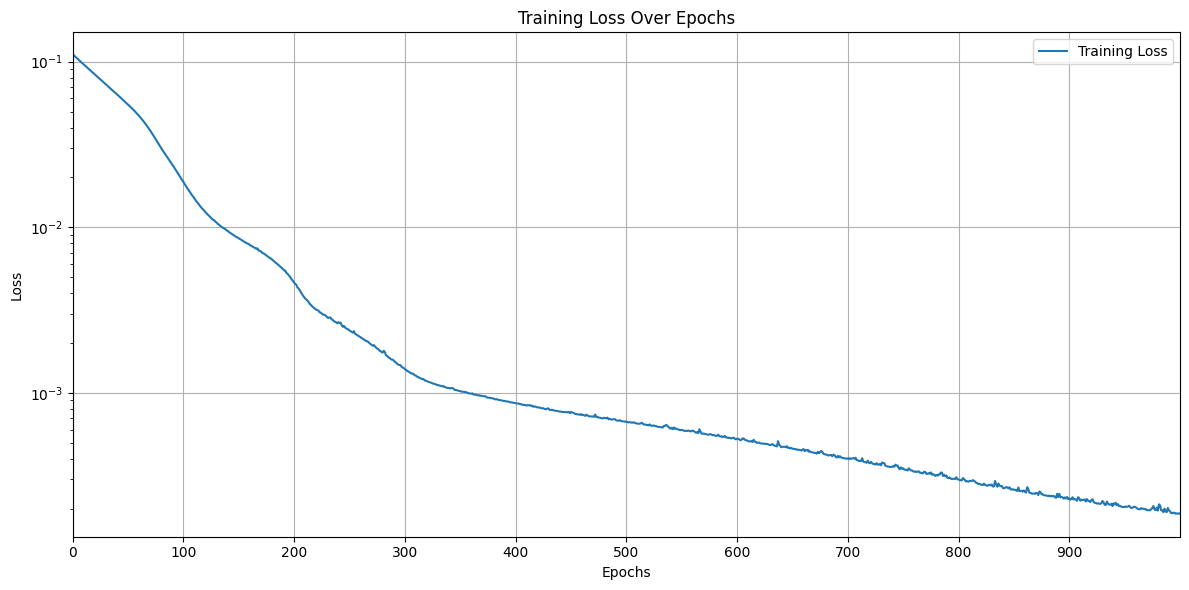

In [75]:
plt.figure(figsize=(12, 6))
colors = matplotlib.colormaps.get_cmap('tab10')

plt.plot(range(1, len(train_losses) + 1), train_losses, label="Training Loss", color=colors(0), linestyle='-')

plt.title("Training Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.xticks(range(0, len(train_losses), len(train_losses) // 10))
plt.xlim(0, len(train_losses))
# plt.ylim(0, 0.001)
plt.yscale('log')
print(f"Minimum loss: {min(train_losses):.6f}")

plt.tight_layout()
plt.show()

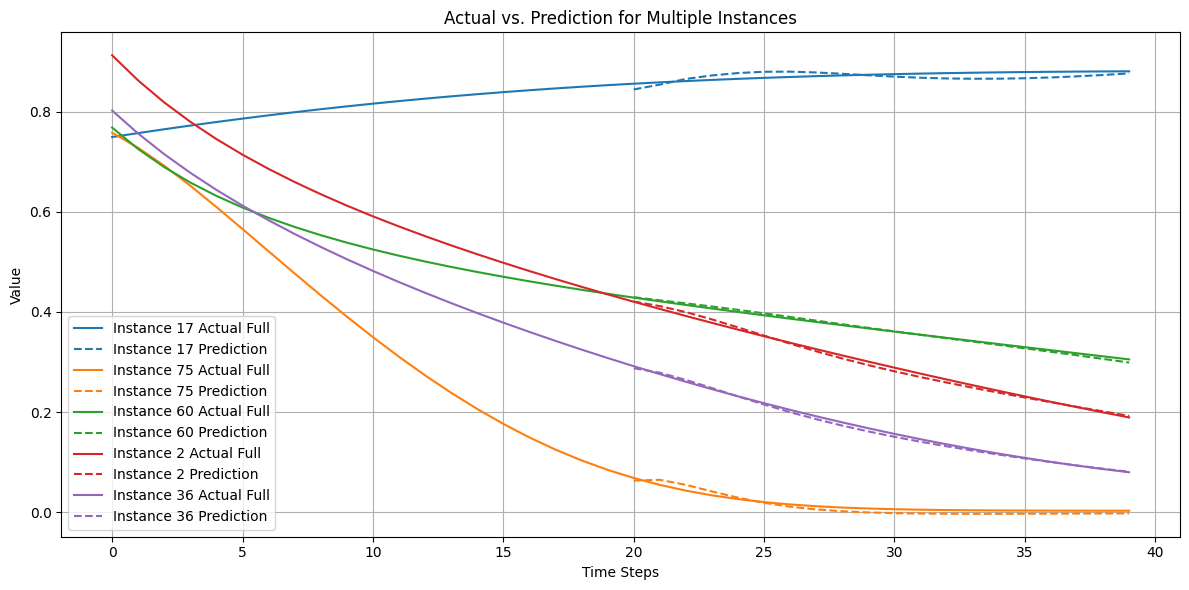

In [77]:
import random

model.eval()

with torch.no_grad():
    future_steps = tgt_len  # user chooses
    pred = model(
        src=X_test,
        tgt_len=future_steps,
        teacher_forcing_ratio=0.0
    )

# Get a list of random indices for the test cases to plot
num_test_cases = X_test.shape[0]
num_plots = 5
random_indices = random.sample(range(num_test_cases), min(num_plots, num_test_cases))

plt.figure(figsize=(12, 6))

# Define a colormap for distinct colors for each instance
colors = matplotlib.colormaps.get_cmap('tab10')

for i_plot, i in enumerate(random_indices):
    # Get a unique color for this instance
    instance_color = colors(i_plot)

    # Combine X_test and Y_test for the complete actual trajectory
    full_trajectory = torch.cat((X_test[i,:,0], Y_test[i,:,0]), dim=0).cpu().numpy()
    plt.plot(full_trajectory, label=f"Instance {i+1} Actual Full", linestyle='-', color=instance_color)

    # Plot prediction data for the current instance
    x_pred = np.arange(X_test.shape[1], X_test.shape[1] + pred.shape[1])
    plt.plot(
        x_pred,
        pred[i,:,0].cpu(),
        label=f"Instance {i+1} Prediction",
        linestyle='--',               # Changed linestyle to dashed for predictions
        color=instance_color
    )

plt.title("Actual vs. Prediction for Multiple Instances")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()